# 实验4 复杂网络的社团检测

1. 给定网络 `1e0w300.csv`，采用 3 种课件算法进行社团检测，输出模块度并对社团划分后的网络进行可视化。
2. 对教材 P144 图 4-19(a) 的网络，参考 `networkx_reference3.0.pdf`，采用派系过滤算法进行社团检测。

## 第一题：1e0w300.csv 的 3 种社团检测算法

In [54]:
# 读取网络数据
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import networkx.algorithms.community as nx_comm
from networkx.algorithms.community import greedy_modularity_communities
from random import randint

protein = pd.read_csv('1e0w300.csv')
G = nx.from_pandas_edgelist(protein, 'source', 'target', edge_attr='weight')

pos = nx.spring_layout(G, seed=10, weight='weight')
node_list = list(G.nodes())
node_index = {node: index for index, node in enumerate(node_list)}


网络社团为： [frozenset({'_:212:_:SER', '_:238:_:ASP', '_:174:_:VAL', '_:172:_:TYR', '_:248:_:ALA', '_:217:_:ASN', '_:264:_:THR', '_:253:_:ASP', '_:263:_:ILE', '_:207:_:HIS', '_:239:_:ILE', '_:221:_:THR', '_:243:_:PRO', '_:234:_:ILE', '_:246:_:THR', '_:242:_:ALA', '_:219:_:ARG', '_:247:_:TYR', '_:256:_:ALA', '_:214:_:TYR', '_:245:_:SER', '_:210:_:SER', '_:178:_:THR', '_:215:_:ASN', '_:233:_:ALA', '_:237:_:LEU', '_:254:_:CYS', '_:235:_:THR', '_:173:_:ASN', '_:205:_:GLN', '_:175:_:GLU', '_:249:_:ASN', '_:204:_:PHE', '_:211:_:GLY', '_:241:_:GLY', '_:176:_:ASN', '_:209:_:ASN', '_:251:_:THR', '_:203:_:GLY', '_:170:_:ASN', '_:257:_:VAL', '_:218:_:PHE', '_:213:_:PRO', '_:244:_:ALA', '_:236:_:GLU', '_:252:_:ASN', '_:208:_:PHE', '_:266:_:TRP', '_:223:_:GLN', '_:179:_:TRP', '_:216:_:SER', '_:222:_:LEU', '_:171:_:ASP', '_:206:_:SER', '_:265:_:VAL', '_:250:_:VAL'}), frozenset({'_:145:_:ARG', '_:108:_:HIS', '_:90:_:PRO', '_:153:_:VAL', '_:107:_:ASP', '_:144:_:GLN', '_:102:_:ARG', '_:98:_:GLY', '_:109:_:I

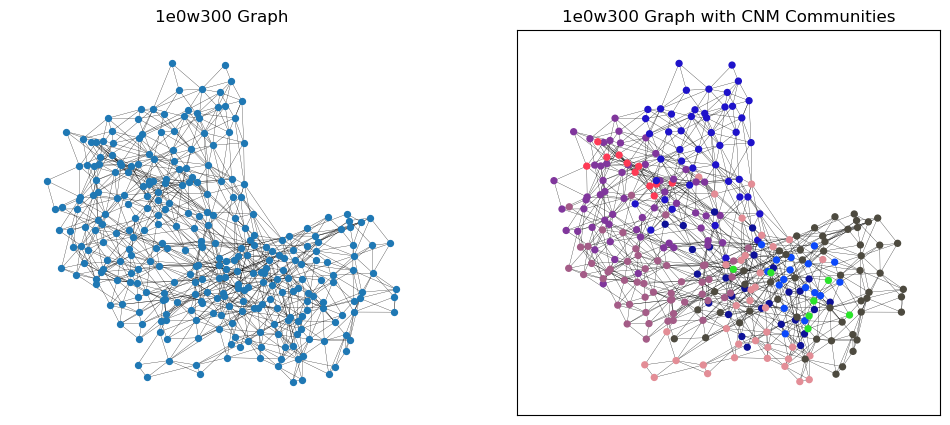

In [56]:
# greedy modularity communities 方法（CNM算法）
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
from random import randint

plt.figure(figsize=(12, 5))
plt.subplot(121)
nx.draw(G, pos, node_size=18, with_labels=False, width=0.2)
plt.title('1e0w300 Graph')

# 使用 greedy modularity（CNM）算法进行社团检测
partitions = greedy_modularity_communities(G, weight='weight')
print('网络社团为：', partitions)

# 计算模块度
Q = nx.community.modularity(G, partitions, weight='weight')
print('模块度Q=', Q)

colors = ['' for x in range(G.number_of_nodes())]
counter = 0
for partition in partitions:
    color = '#%06X' % randint(0, 0xFFFFFF)
    counter += 1

    for node in partition:
        colors[node_index[node]] = color

print('社团数量为：', counter)
plt.axis('off')
plt.subplot(122)
nx.draw_networkx(G, pos, nodelist=node_list, node_size=18, with_labels=False, width=0.2, node_color=colors)
plt.title('1e0w300 Graph with CNM Communities')
plt.show()


网络社团为： [{'_:4:_:THR', '_:3:_:SER', '_:300:_:LEU', '_:16:_:PHE', '_:37:_:GLU', '_:36:_:ARG', '_:7:_:ALA', '_:302:_:GLY', '_:8:_:ALA', '_:283:_:PHE', '_:299:_:ALA', '_:288:_:SER', '_:293:_:TYR', '_:38:_:PHE', '_:294:_:THR', '_:2:_:GLU', '_:12:_:SER', '_:289:_:LYS', '_:291:_:ALA', '_:287:_:GLY', '_:255:_:LEU', '_:286:_:ASP', '_:18:_:THR', '_:14:_:ARG', '_:290:_:LYS', '_:11:_:GLN', '_:5:_:LEU', '_:301:_:ASN', '_:6:_:GLY', '_:298:_:ASP', '_:17:_:GLY', '_:285:_:ASN', '_:9:_:ALA', '_:282:_:LEU', '_:297:_:LEU', '_:39:_:ASN', '_:13:_:GLY', '_:295:_:ALA', '_:296:_:VAL', '_:10:_:ALA', '_:292:_:ALA', '_:1:_:ALA', '_:284:_:ASN'}, {'_:261:_:LEU', '_:232:_:VAL', '_:77:_:GLN', '_:264:_:THR', '_:121:_:VAL', '_:120:_:ILE', '_:263:_:ILE', '_:234:_:ILE', '_:262:_:GLY', '_:259:_:ARG', '_:231:_:ASP', '_:122:_:GLN', '_:15:_:TYR', '_:40:_:MET', '_:233:_:ALA', '_:254:_:CYS', '_:79:_:ARG', '_:260:_:CYS', '_:78:_:VAL', '_:258:_:SER'}, {'_:272:_:ASP', '_:32:_:SER', '_:69:_:ASN', '_:31:_:THR', '_:26:_:SER', '_:76:

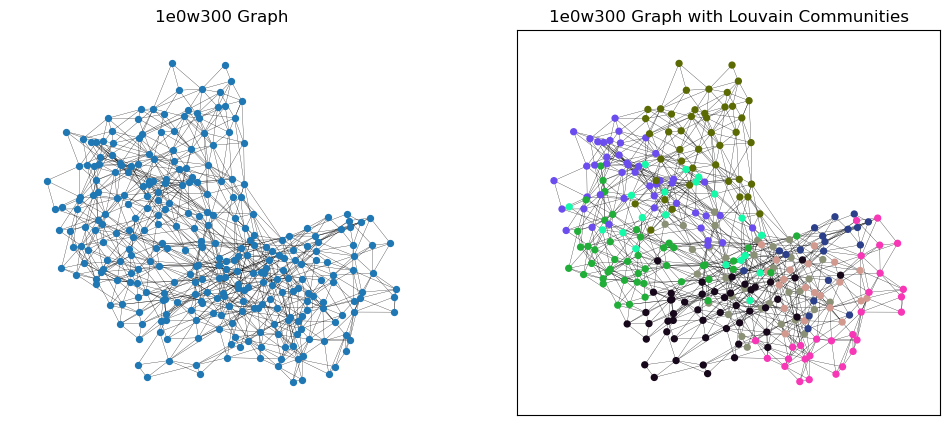

In [57]:
# Louvain 算法
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from random import randint

plt.figure(figsize=(12, 5))
plt.subplot(121)
nx.draw(G, pos, node_size=18, with_labels=False, width=0.2)
plt.title('1e0w300 Graph')

# 使用 Louvain 算法进行社团检测
partition = nx_comm.louvain_communities(G, weight='weight', seed=10)
print('网络社团为：', partition)

# 计算模块度
Q = nx_comm.modularity(G, partition, weight='weight')
print('模块度Q=', Q)

# 初始化颜色列表，用于存储每个节点的颜色
colors = ['' for _ in range(G.number_of_nodes())]

# 为每个社团分配随机颜色
for com in partition:
    # 生成一个随机的十六进制颜色代码（RGB）
    color = '#%06X' % randint(0, 0xFFFFFF)
    # 为当前社团的所有节点分配相同的颜色
    for node in com:
        colors[node_index[node]] = color

print('社团数量：', len(partition))
plt.axis('off')
plt.subplot(122)
nx.draw_networkx(G, pos, nodelist=node_list, node_size=18, with_labels=False, width=0.2, node_color=colors)
plt.title('1e0w300 Graph with Louvain Communities')
plt.show()


网络社团为： [{'_:301:_:ASN', '_:1:_:ALA', '_:298:_:ASP', '_:302:_:GLY', '_:299:_:ALA', '_:2:_:GLU'}, {'_:297:_:LEU', '_:292:_:ALA', '_:38:_:PHE', '_:4:_:THR', '_:3:_:SER', '_:300:_:LEU', '_:37:_:GLU', '_:296:_:VAL', '_:16:_:PHE', '_:8:_:ALA', '_:9:_:ALA', '_:282:_:LEU', '_:293:_:TYR', '_:5:_:LEU'}, {'_:7:_:ALA', '_:39:_:ASN', '_:6:_:GLY', '_:10:_:ALA'}, {'_:12:_:SER', '_:13:_:GLY', '_:11:_:GLN'}, {'_:34:_:ALA', '_:32:_:SER', '_:30:_:TYR', '_:26:_:SER', '_:31:_:THR', '_:29:_:THR', '_:36:_:ARG', '_:24:_:ARG', '_:28:_:SER', '_:25:_:LEU', '_:27:_:ASP', '_:33:_:ILE', '_:35:_:GLY'}, {'_:272:_:ASP', '_:238:_:ASP', '_:283:_:PHE', '_:207:_:HIS', '_:239:_:ILE', '_:240:_:GLN', '_:19:_:ALA', '_:277:_:GLU', '_:242:_:ALA', '_:271:_:SER', '_:268:_:VAL', '_:279:_:THR', '_:237:_:LEU', '_:175:_:GLU', '_:290:_:LYS', '_:267:_:GLY', '_:276:_:SER', '_:241:_:GLY', '_:274:_:TRP', '_:273:_:SER', '_:270:_:ASP', '_:275:_:ARG', '_:281:_:LEU', '_:280:_:PRO', '_:266:_:TRP', '_:208:_:PHE', '_:278:_:GLN', '_:269:_:ARG', '

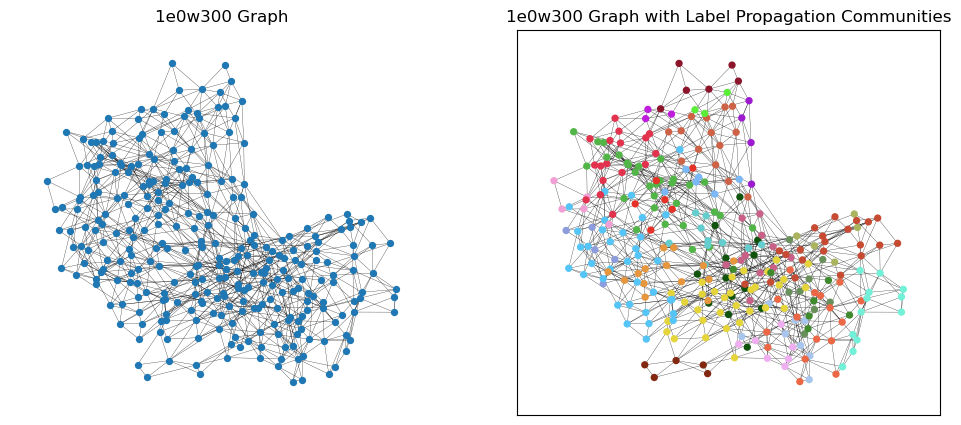

In [59]:
# 利用标签传播算法进行社团检测
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from random import randint

plt.figure(figsize=(12, 5))
plt.subplot(121)
nx.draw(G, pos, node_size=18, with_labels=False, width=0.2)
plt.title('1e0w300 Graph')

# 标签传播算法进行社团检测
partition = list(nx.community.label_propagation_communities(G))
print('网络社团为：', partition)

Q = nx_comm.modularity(G, partition, weight='weight')
print('模块度Q=', Q)

colors = ['' for x in range(G.number_of_nodes())]
counter = 0
for com in partition:
    color = '#%06X' % randint(0, 0xFFFFFF)
    counter += 1
    for node in list(com):
        colors[node_index[node]] = color

print('社团数量为：', len(partition))
plt.axis('off')
plt.subplot(122)
nx.draw_networkx(G, pos, nodelist=node_list, node_size=18, with_labels=False, width=0.2, node_color=colors)
plt.title('1e0w300 Graph with Label Propagation Communities')
plt.show()


### 三种算法结果分析

1. CNM 算法以模块度贪心增大为目标，划分结果通常比较稳定，得到的社团结构较清晰，适合做基础社团检测实验。
2. Louvain 算法也是基于模块度优化，但采用了多层聚合思想，通常能得到更高的模块度，且在较大网络上运行速度较快。
3. 标签传播算法不直接优化模块度，而是通过节点标签在网络中传播形成社团，因此运行速度快，但结果稳定性相对较弱，划分出的社团数量往往更多。
4. 在本实验网络上，Louvain 算法得到的模块度通常最高，CNM 次之，标签传播算法的模块度相对较低，因此从社团划分质量看，Louvain 效果最好。

## 第二题：教材 P144 图 4-19(a) 的派系过滤算法

按照教材图 4-19(a) 手工构造网络，再使用 `networkx.algorithms.community.k_clique_communities` 进行 4-派系社团检测。

--- 算法执行完毕 ---
网络节点总数: 10, 边总数: 24
极大派系为：[[9, 3, 5], [4, 1, 2, 3], [4, 2, 8, 7], [4, 5, 3], [4, 5, 6, 8, 7], [4, 5, 6, 10]]
4-派系社团为：[[1, 2, 3, 4], [2, 4, 5, 6, 7, 8, 10]]
--------------------


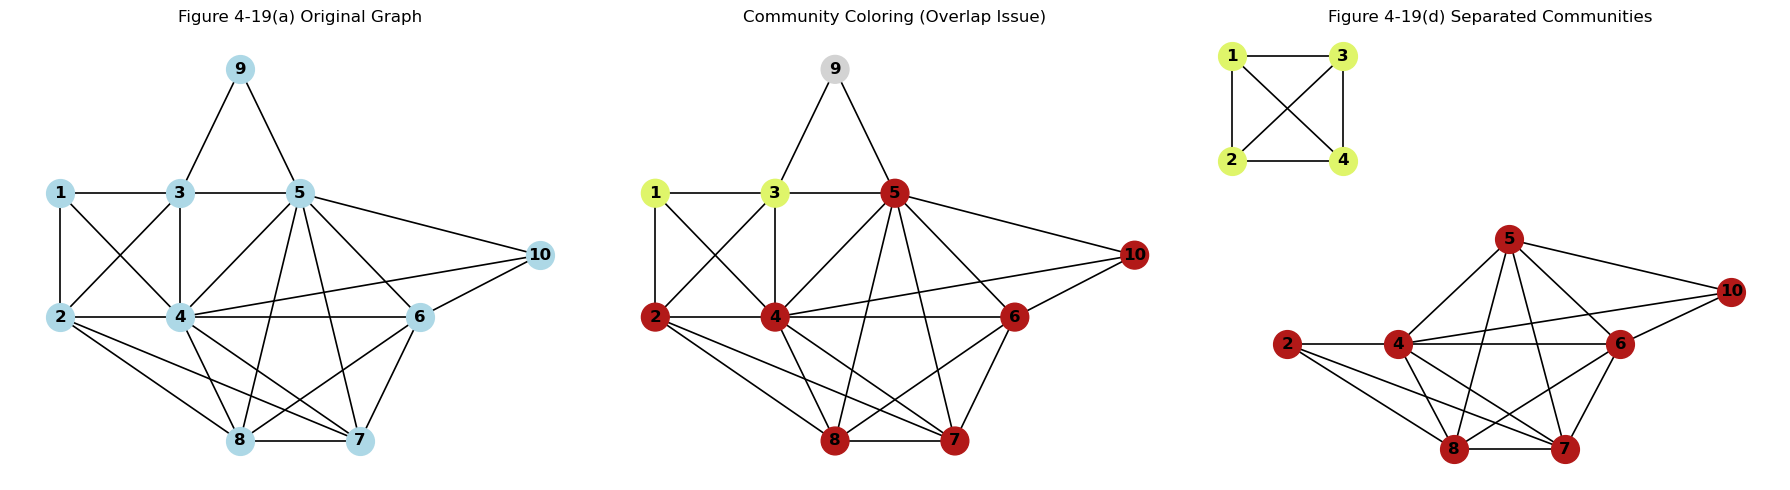

In [81]:
# ==========================================
# 第一部分：数据构建与算法执行 (Algorithm & Data)
# ==========================================
import networkx as nx
from networkx.algorithms.community import k_clique_communities

# 1. 构建网络图数据
G = nx.Graph()
edges = [
    # 左侧的 4-派系 (节点 1, 2, 3, 4)
    (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4),
    # 中间的 5-派系 (节点 4, 5, 6, 7, 8)
    (4, 5), (4, 6), (4, 7), (4, 8), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8),
    # 额外补充的连线
    (2, 7), (2, 8),
    # 顶部节点 9 相关的边 (构成 4-派系 {3, 4, 5, 9})
    (3, 5), (3, 9), (5, 9),
    # 右侧节点 10 相关的边 (构成 4-派系 {4, 5, 6, 10})
    (4, 10), (5, 10), (6, 10)
]
G.add_edges_from(edges)

# 2. 执行核心算法
k = 4
# 寻找极大派系
cliques = list(nx.find_cliques(G))
# 利用 k-clique 算法划分重叠社团
partition = list(k_clique_communities(G, k, cliques))

# 3. 整理算法结果
# 将社团按包含节点数量从小到大排序，方便后续稳定处理
partition_sorted = sorted([list(com) for com in partition], key=len)

# 打印算法输出
print("--- 算法执行完毕 ---")
print(f"网络节点总数: {G.number_of_nodes()}, 边总数: {G.number_of_edges()}")
print(f"极大派系为：{cliques}")
print(f"{k}-派系社团为：{partition_sorted}")
print("-" * 20)


# ==========================================
# 第二部分：可视化呈现 (Visualization)
# ==========================================
import matplotlib.pyplot as plt
from random import randint

# 1. 定义节点在二维平面上的绝对物理坐标
pos = {
    1: (1, 4),  2: (1, 2),  
    3: (3, 4),  4: (3, 2),  
    5: (5, 4),  6: (7, 2),  
    7: (6, 0),  8: (4, 0),  
    9: (4, 6),  10: (9, 3)
}

# 为每个划分好的社团提前生成固定的随机颜色
com_colors = ['#%06X' % randint(0, 0xFFFFFF) for _ in range(len(partition_sorted))]

# 初始化画布，设置比例为 1:3 容纳三个子图
plt.figure(figsize=(18, 5))

# --- 绘制图 1：原始网络图 ---
plt.subplot(131)
nx.draw(G, pos, node_color='lightblue', node_size=400, with_labels=True, width=1.2, font_weight='bold')
plt.title('Figure 4-19(a) Original Graph')


# --- 绘制图 2：重叠涂色图 (直接在原位上色) ---
# 初始化所有节点为浅灰色
colors_overlap = ['lightgray' for _ in range(G.number_of_nodes())]
node_list = list(G.nodes())
node_index = {node: index for index, node in enumerate(node_list)}

# 根据算法结果上色 (重叠节点会被后遍历到的社团颜色覆盖)
for idx, com in enumerate(partition_sorted):
    for node in com:
        colors_overlap[node_index[node]] = com_colors[idx]

plt.subplot(132)
nx.draw_networkx(G, pos, nodelist=node_list, node_size=400, with_labels=True, width=1.2, node_color=colors_overlap, font_weight='bold')
plt.title('Community Coloring (Overlap Issue)')
plt.axis('off')


# --- 绘制图 3：物理空间分离图 (模拟教材图 d) ---
plt.subplot(133)
plt.title('Figure 4-19(d) Separated Communities')

# 设置平移偏移量：让社团在画板上错开位置
offsets = [(-1, 3.5), (0, 0)] 

for idx, com in enumerate(partition_sorted):
    # 根据算法结果，将当前社团作为独立的子图提取出来
    sub_G = G.subgraph(com)
    
    # 计算当前子图的偏移坐标
    dx, dy = offsets[idx % len(offsets)]
    pos_separated = {node: (pos[node][0] + dx, pos[node][1] + dy) for node in sub_G.nodes()}
    
    # 绘制独立的子图
    nx.draw_networkx(sub_G, pos_separated, node_size=400, node_color=com_colors[idx], with_labels=True, width=1.2, font_weight='bold')

plt.axis('off')
plt.tight_layout()
plt.show()

### 第二题结果说明

1. `k_clique_communities(G, 4)` 表示寻找 4-派系社团，即由大小为 4 的派系通过共享 3 个节点连接而成的社团。
2. 该网络中可以得到 2 个 4-派系社团，其中一个为左侧的 4 节点完全子图，另一个为右侧由多个重叠 4-派系合并得到的大社团。
3. 派系过滤算法的特点是能够识别重叠紧密子结构，适合发现网络中的高凝聚社团。